In [282]:
%config InlineBackend.figure_format = 'retina'
%autosave 60

Autosaving every 60 seconds


In [283]:
import pandas as pd
import numpy as np
from ambrosia.preprocessing import RobustPreprocessor
from ambrosia.designer import Designer

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

from rich import print

In [284]:
import matplotlib.pyplot as plt

plt.style.use("styles/ab_test.mplstyle")

import matplotlib.pyplot as plt
plt.style.use("styles/ab_test.mplstyle")

from styles.plot_helpers import *


#### Data load

In [285]:
df_original = pd.read_csv('data/ab_test_dataset.csv')

In [254]:
summary = pd.DataFrame({
    'dtype': df_original.dtypes,
    'nunique': df_original.nunique(),
    'nulls': df_original.isna().sum(),
    'min': df_original.min().round(),
    'median': df_original.median().round(2),
    'max': df_original.max().round(),
})

print(summary.to_string())
print('Total rows:', len(df_original))

dtype  nunique  nulls     min    median       max
user_id                  int64     2236      0     0.0   5454.50   11191.0
total_spending           int64     1054      0     5.0    396.50    2525.0
num_web_purchases        int64       15      0     0.0      4.00      27.0
num_catalog_purchases    int64       14      0     0.0      2.00      28.0
num_store_purchases      int64       14      0     0.0      5.00      13.0
num_deals_purchases      int64       15      0     0.0      2.00      15.0
num_web_visits_month     int64       16      0     0.0      6.00      20.0
recency                  int64      100      0     0.0     49.00      99.0
lifetime_months          int64       24      0     0.0     11.00      23.0
complain                 int64        2      0     0.0      0.00       1.0
income                 float64     1971      0  1730.0  51381.50  162397.0
age                      int64       56      0    18.0     44.00      74.0
children                 int64        4      0     0.0      1.00       3.0
family_size              int64        5      0     1.0      3.00       5.0
wines_share            float64     1745      0     0.0      0.46       1.0
fruits_share           float64     1335      0     0.0      0.03       0.0
meat_share             float64     1648      0     0.0      0.23       1.0
fish_share             float64     1368      0     0.0      0.05       1.0
sweets_share           float64     1307      0     0.0      0.03       1.0
gold_share             float64     1576      0     0.0      0.09       1.0
cluster_kmeans           int64        3      0     0.0      1.00       2.0

Total rows: 2236

In [255]:
display(df_original.sample(5))

,user_id,total_spending,num_web_purchases,num_catalog_purchases,num_store_purchases,num_deals_purchases,num_web_visits_month,recency,lifetime_months,complain,income,age,children,family_size,wines_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,cluster_kmeans
1840,3170,1042,4,4,6,1,2,86,10,0,68148.0,57,0,2,0.373321,0.063340,0.391555,0.035509,0.054702,0.081574,1
919,4487,95,2,0,4,1,6,67,17,0,39858.0,45,1,2,0.157895,0.210526,0.263158,0.021053,0.073684,0.273684,2
708,1272,903,7,5,10,4,5,49,20,0,55250.0,49,1,2,0.735327,0.064230,0.091916,0.035437,0.000000,0.073090,0
1663,6912,772,6,3,12,1,4,60,10,0,63246.0,47,2,4,0.768135,0.038860,0.117876,0.037565,0.028497,0.009067,0
329,663,71,1,1,3,1,4,46,9,0,33996.0,25,0,1,0.563380,0.028169,0.211268,0.112676,0.000000,0.084507,0


Точный период, к которому относятся агрегированные данные, не указан явно. По значениям метрик можно сделать вывод, что они приведены к месячному уровню. Средний объем трат (TotalSpent ~200–800) и количество визитов (NumWebVisitsMonth ~5) соответствуют типичному месячному поведению пользователя, а не годовому.

В связи с этим предполагаю, что данные отражают активность пользователей за один месяц.

In [256]:
df = df_original.copy()

---

# Introduction

Платформа продает продукты с акцентом на винный ассортимент. Основная бизнес-задача – увеличение выручки за счет роста среднего чека.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
  Обоснование гипотезы
</p>
В ходе предварительного анализа данных была проведена кластеризация пользователей, которая выявила наличие трех сегментов с различными паттернами поведения.
Сегменты отличаются по структуре потребления и уровню трат, что указывает на гетерогенность пользовательской базы.

Это позволяет предположить, что единый подход к рекомендациям может быть неэффективен, и персонализация контента с учетом особенностей сегментов может привести к увеличению среднего чека и выручки.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Гипотеза:
</p>
H0: персонализация не влияет на средний чек<br/>
H1: персонализация влияет на средний чек

Ожидаемый эффект: 10-15%.\
Размер выборки ограничен (~2000 пользователей), что ограничивает обнаружение малых эффектов.


<p style="padding: 10px 0;">
<span style="font-weight: 700; font-size: 1.2em; color: teal;">
Задача A/B теста</span> – проверить гипотезу о том, что персонализация рекомендаций приводит к увеличению среднего чека.<p>

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Дизайн эксперимента</p>
Пользователи случайным образом делятся на две группы:

A — стандартные рекомендации\
B — персонализированные рекомендации

Основная метрика: `AvgPurchaseValue`\
Дополнительные метрики: `TotalSpent`, `NumPurchases`

Данные агрегированы на уровне пользователя и интерпретируются как срез за условный месячный период. Это позволяет использовать их для имитации A/B теста, однако результаты следует рассматривать в рамках статической модели.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Логика персонализации
</p>
Персонализация реализуется на основе сегментов с учетом структуры типовой корзины:\
- для сегмента Wine-focused акцент на кросс-селлинг (сопутствующие товары к вину) 
- для сегмента Wine & Meat готовые решения (наборы, комплекты) 
- для сегмента Balanced акционные предложения и скидки 

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Проведение эксперимента
</p>

Пользователь при первом взаимодействии с платформой случайным образом распределяется в одну из групп (A или B) и закрепляется в ней на весь период эксперимента.

В группе A пользователю показываются стандартные рекомендации, сформированные без учета сегмента, в группе B персонализированные рекомендации, основанные на сегменте пользователя и структуре его потребления. Рекомендации отображаются в основных точках взаимодействия с пользователем (каталог, карточка товара, блок рекомендаций).

Тест проводится одновременно для обеих групп и при одинаковых условиях (без параллельных изменений и с учетом сезонности). Эксперимент продолжается до набора необходимого количества пользователей, рассчитанного на этапе дизайна.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Анализ результатов
</p>
Для оценки эффекта сравниваются значения метрик в контрольной и тестовой группах.
Метрики агрегируются на уровне пользователя за период эксперимента. Основная метрика (AvgPurchaseValue) рассчитывается как средний чек пользователя, дополнительные метрики используются для интерпретации эффекта. Результаты также рассматриваются в разрезе сегментов пользователей, чтобы определить различия в эффекте между кластерами.




---

#### Описание сегментов пользователей

Пользователи заметно различаются по поведению, что позволяет выделить три сегмента:
- Wine-focused: покупают в основном вино, корзина узкая\
Потенциал: расширение корзины через сопутствующие товары

- Wine & Meat: высокий средний чек, слабая реакция на скидки\
Потенциал: рост чека через наборы и готовые решения

- Balanced: низкий средний чек, высокая чувствительность к скидкам\
Потенциал: рост объема покупок через акции

Сегменты заметно отличаются по поведению, это видно на графике разбиения пользователей на сегменты.

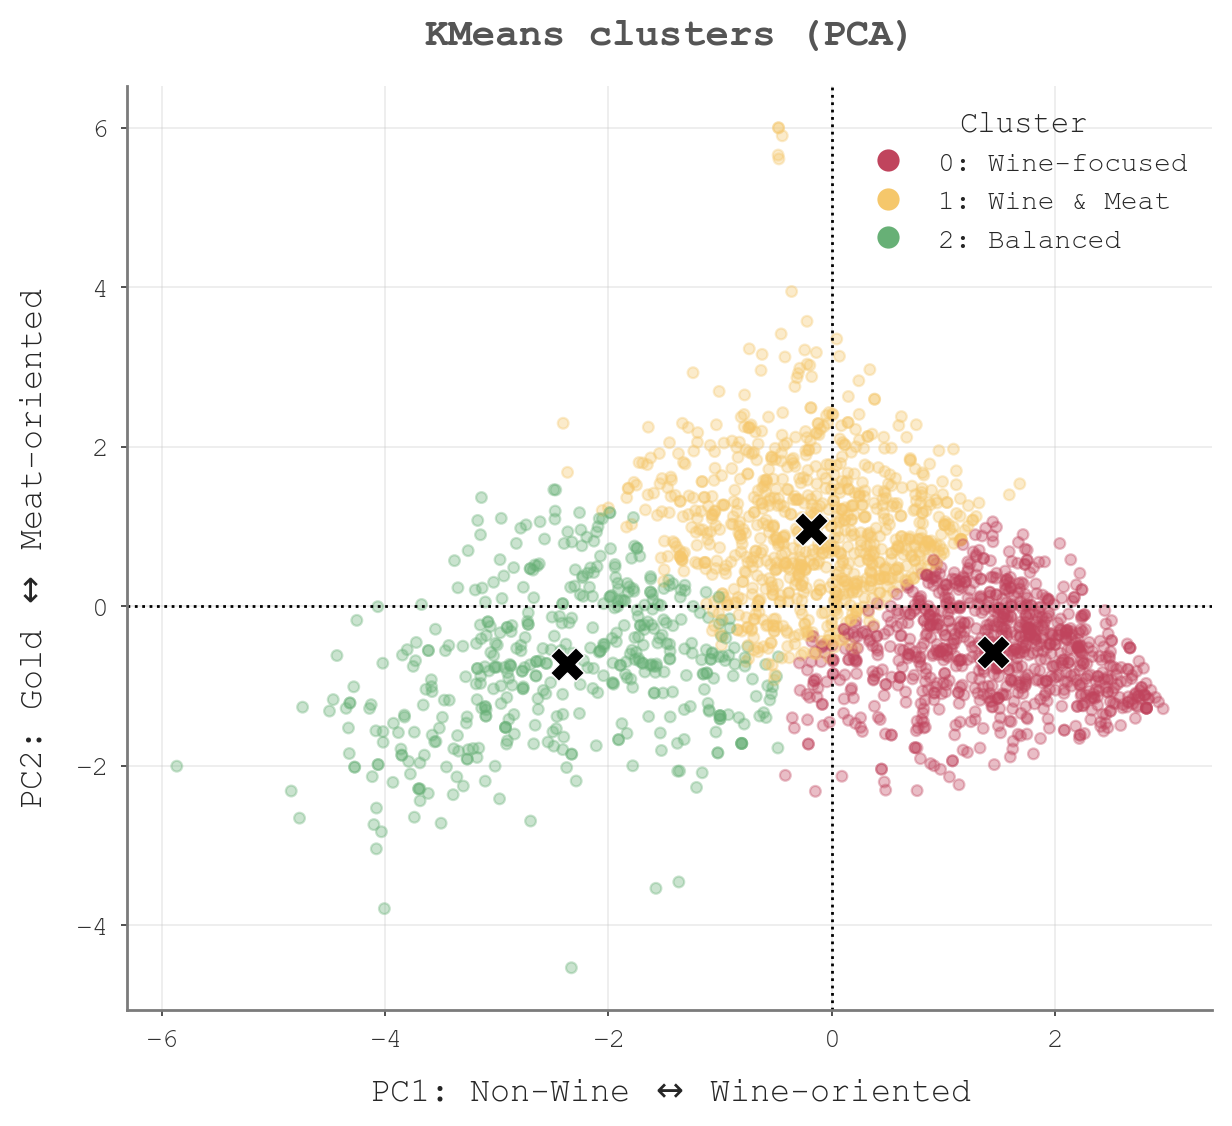

In [257]:
from IPython.display import Image, display
display(Image(filename="clusters.png", width=700))

#### Анализ поведения клиентов по сегментам

In [258]:
# метки для кластеров
def assign_segment(row):
    wine = row['wines_share']
    meat = row['meat_share']
    
    if wine > 0.5:
        return 'Wine-focused'
    elif wine > 0.3 and meat > 0.3:
        return 'Wine & Meat'
    else:
        return 'Balanced'

##### **Структура средней корзины в сегменте**

In [259]:
features_consumption = [
    'wines_share', 'fruits_share', 'meat_share',
    'fish_share', 'sweets_share', 'gold_share'
]

Профиль типичной покупательской корзины в сегменте

cluster_kmeans,segment,wines_share,fruits_share,meat_share,fish_share,sweets_share,gold_share
0,Wine-focused,0.68,0.02,0.16,0.03,0.02,0.09
1,Wine & Meat,0.38,0.05,0.36,0.07,0.05,0.09
2,Balanced,0.18,0.11,0.20,0.15,0.11,0.24


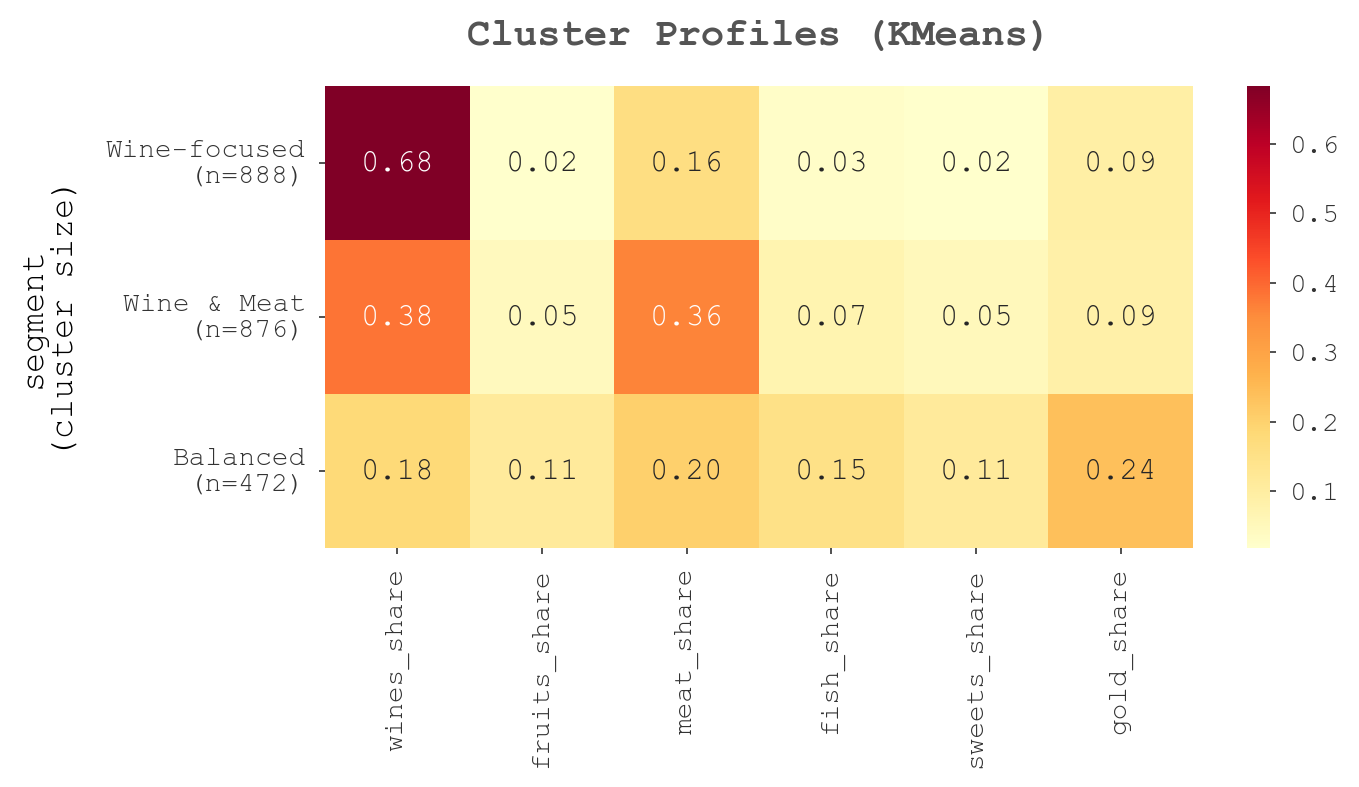

In [260]:
# профиль потребительской корзины
basket_profile = (
    df
    .groupby('cluster_kmeans')[features_consumption]
    .mean()
    .round(2)
    .reset_index()
)

# присвоение меток кластеров
basket_profile['segment'] = basket_profile.apply(assign_segment, axis=1)

# сортировка столбцов
cols = ['cluster_kmeans', 'segment'] + [
    c for c in basket_profile.columns if c not in ['cluster_kmeans', 'segment']
]
basket_profile = basket_profile[cols]

# вывод таблицы
cols_to_round = [
    'wines_share', 'fruits_share', 'meat_share',
    'fish_share', 'sweets_share', 'gold_share'
]

print("Профиль типичной покупательской корзины в сегменте")
display(
    basket_profile.style
    .format({col: "{:.2f}" for col in cols_to_round})
    .hide(axis='index')
)

# размеры кластеров
sizes = df['cluster_kmeans'].value_counts().sort_index()

# средние профили
cluster_means = (
    df.groupby('cluster_kmeans')[features_consumption]
    .mean()
    .sort_index()
)

# метки из basket_profile
segment_labels = (
    basket_profile
    .set_index('cluster_kmeans')['segment']
    .sort_index()
)

# подписи для heatmap
cluster_means.index = [
    f"{segment_labels.loc[i]}\n(n={sizes.loc[i]})"
    for i in cluster_means.index
]

plt.figure(figsize=(7, 3))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="YlOrRd")
plt.grid(False)
plt.title("Cluster Profiles (KMeans)")
plt.ylabel("segment\n(cluster size)")
plt.show()

В сегменте Wine-focused клиенты покупают в основном вино (доля 0.68) и мало интересуются остальными видами товаров.\
В семгенте Wine & Meat	доля вина 0.38 и близкая по величине доля мяса 0.36.\
В сегменте Balanced средняя корзина покупателей более сбалансированная, с акцентом на товары категории Gold. 

##### **Профиль поведения среднего покупателя в сегменте**

In [261]:
# суммарное количество покупок
df['total_purchases'] = (
    df['num_web_purchases'] +
    df['num_catalog_purchases'] +
    df['num_store_purchases']
)

# средняя стоимость покупки
df['avg_purchase_value'] = np.where(
    df['total_purchases'] > 0,
    df['total_spending'] / df['total_purchases'], 0)

# доля покупок по акциям
df['deals_share'] = np.where(
    df['total_purchases'] > 0,
    df['num_deals_purchases'] / df['total_purchases'], 0)

# доля канала: веб
df['web_share'] = np.where(
    df['total_purchases'] > 0,
    df['num_web_purchases'] / df['total_purchases'], 0)

# доля канала: каталог
df['catalog_share'] = np.where(
    df['total_purchases'] > 0,
    df['num_catalog_purchases'] / df['total_purchases'], 0)

# доля канала: магазин
df['store_share'] = np.where(
    df['total_purchases'] > 0,
    df['num_store_purchases'] / df['total_purchases'], 0)

In [262]:
# профиль поведения
behaviour_cols = [
    'lifetime_months', 'total_spending',
    'avg_purchase_value', 'deals_share',
    'web_share', 'catalog_share', 'store_share',
    'num_web_visits_month', 'complain'
]

behaviour_profile = (
    df
    .groupby('cluster_kmeans')[behaviour_cols]
    .mean()
    .reset_index()
)

# добавляем сегменты
behaviour_profile_full = behaviour_profile.merge(
    basket_profile[['cluster_kmeans', 'segment']],
    on='cluster_kmeans'
)

# порядок колонок
cols = ['cluster_kmeans', 'segment'] + behaviour_cols

# округление
cols_to_round = behaviour_cols

# вывод
print("Профиль поведения покупателя в сегменте")

display(
    behaviour_profile_full[cols]
    .style
    .format({col: "{:.2f}" for col in cols_to_round})
    .hide(axis='index')
)

Профиль поведения покупателя в сегменте

cluster_kmeans,segment,lifetime_months,total_spending,avg_purchase_value,deals_share,web_share,catalog_share,store_share,num_web_visits_month,complain
0,Wine-focused,11.47,611.38,37.61,0.25,0.35,0.16,0.49,5.77,0.01
1,Wine & Meat,10.92,796.72,48.09,0.22,0.31,0.20,0.49,4.55,0.01
2,Balanced,11.21,241.84,20.48,0.29,0.32,0.12,0.55,5.88,0.01


По таблице видны различия в показателях между сегментами. Lifetime клиентов в системе выглядит примерно одинаковым, параметры трат существенно отличаются, доли каналов отличаются в меньшей степени. Уровень Complain незначителен. Проверим, являются ли эти различия статистически значимыми.

In [263]:
from scipy.stats import f_oneway, kruskal

# ANOVA

features_to_test = [
    'lifetime_months',
    'total_spending',
    'avg_purchase_value',
    'deals_share',
    'web_share',
    'catalog_share',
    'store_share',
    'num_web_visits_month'
]

results = []

for feature in features_to_test:
    groups = [
        df[df['cluster_kmeans'] == k][feature]
        for k in sorted(df['cluster_kmeans'].unique())
    ]
    
    f_stat, p_anova = f_oneway(*groups)
    h_stat, p_kruskal = kruskal(*groups)
    
    results.append({
        'feature': feature,
        'f_stat': round(f_stat, 3),
        'p_anova': round(p_anova, 5),
        'p_kruskal': round(p_kruskal, 5)
    })

anova_results = pd.DataFrame(results).sort_values('p_anova')

anova_results

,feature,f_stat,p_anova,p_kruskal
1,total_spending,147.513,0.00000,0.00000
2,avg_purchase_value,58.474,0.00000,0.00000
4,web_share,24.647,0.00000,0.00000
5,catalog_share,51.434,0.00000,0.00000
6,store_share,24.794,0.00000,0.00000
7,num_web_visits_month,76.551,0.00000,0.00000
3,deals_share,5.477,0.00424,0.00000
0,lifetime_months,1.511,0.22095,0.20961


Тесты ANOVA и Kruskal-Wallis подтверждают статистическую значимость различий между сегментами по поведенческим метрикам. Самые сильные различия по общему объему трат Total_spending (F=147.5, p<0.001), среднему чеку Avg_purchase_value (F=58.5, p<0.001) и долям каналов покупок.

По доле покупок по акциям различия тоже есть, но слабее (F=5.48, p=0.004).\
По длительности взаимодействия с компанией различий нет (F=1.51, p=0.22).

---

# Preprocessing

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 10px 0;">
Основные метрики
</p>

In [264]:
primary_metrics = [
    'avg_purchase_value',
    'total_spending'
]

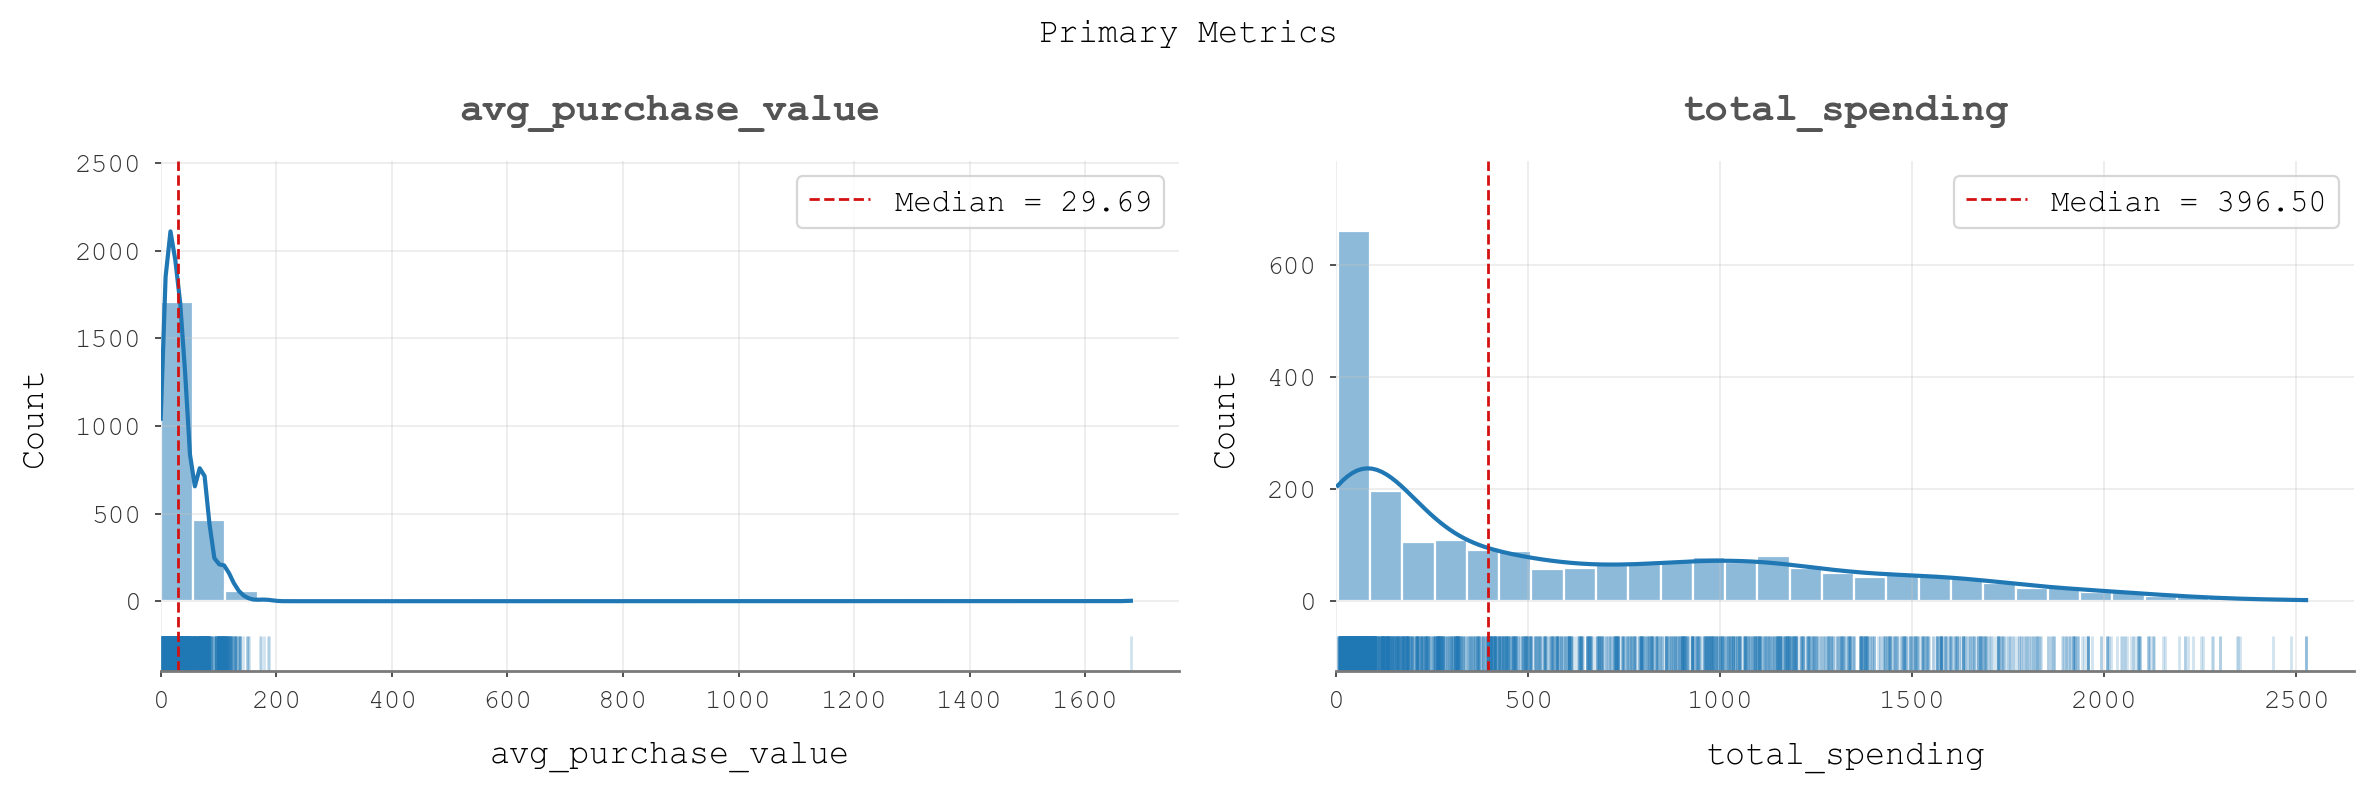

avg_purchase_value skew: 20.807

In [265]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, col in enumerate(primary_metrics):
    median_val = df[col].median()
    
    sns.rugplot(data=df, x=col, height=0.07, alpha=0.2, ax=axes[idx])
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[idx])

    axes[idx].axvline(median_val,
        color=DIMRED, linestyle='--', linewidth=1,
        label=f'Median = {median_val:.2f}'
    )
    
    axes[idx].set_title(col)
    axes[idx].set_xlim(left=0)
    axes[idx].spines['left'].set_visible(False)
    axes[idx].legend()

plt.suptitle("Primary Metrics", fontsize=12)
plt.tight_layout()
plt.show()

print(f"avg_purchase_value skew: {df['avg_purchase_value'].skew():.3f}")


У avg_purchase_value хвост есть, но основная масса значений достаточно компактная: средний чек относительно стабильный, и изменения в интерфейсе должны в нем проявляться заметнее.

У total_spending хвост гораздо тяжелее: есть крупные покупатели, которые сильно увеличивают разброс значений. В результате метрика становится менее стабильной — различия между группами могут возникать из-за случайного попадания таких пользователей, а не из-за реального эффекта.

Для основной метрики важно уменьшить влияние крайних значений, чтобы повысить чувствительность теста. Обрежем только небольшой правый хвост распределения, чтобы снизить влияние экстремальных значений, не искажая общую структуру данных.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 10px 0;">
Дополнительные метрики
</p>

In [266]:
df['purchases_per_visit'] = np.where(
    df['num_web_visits_month'] > 0,
    df['total_purchases'] / df['num_web_visits_month'], 0)

In [267]:
secondary_metrics = [
    'total_purchases',
    'purchases_per_visit',
    'num_web_visits_month'
]

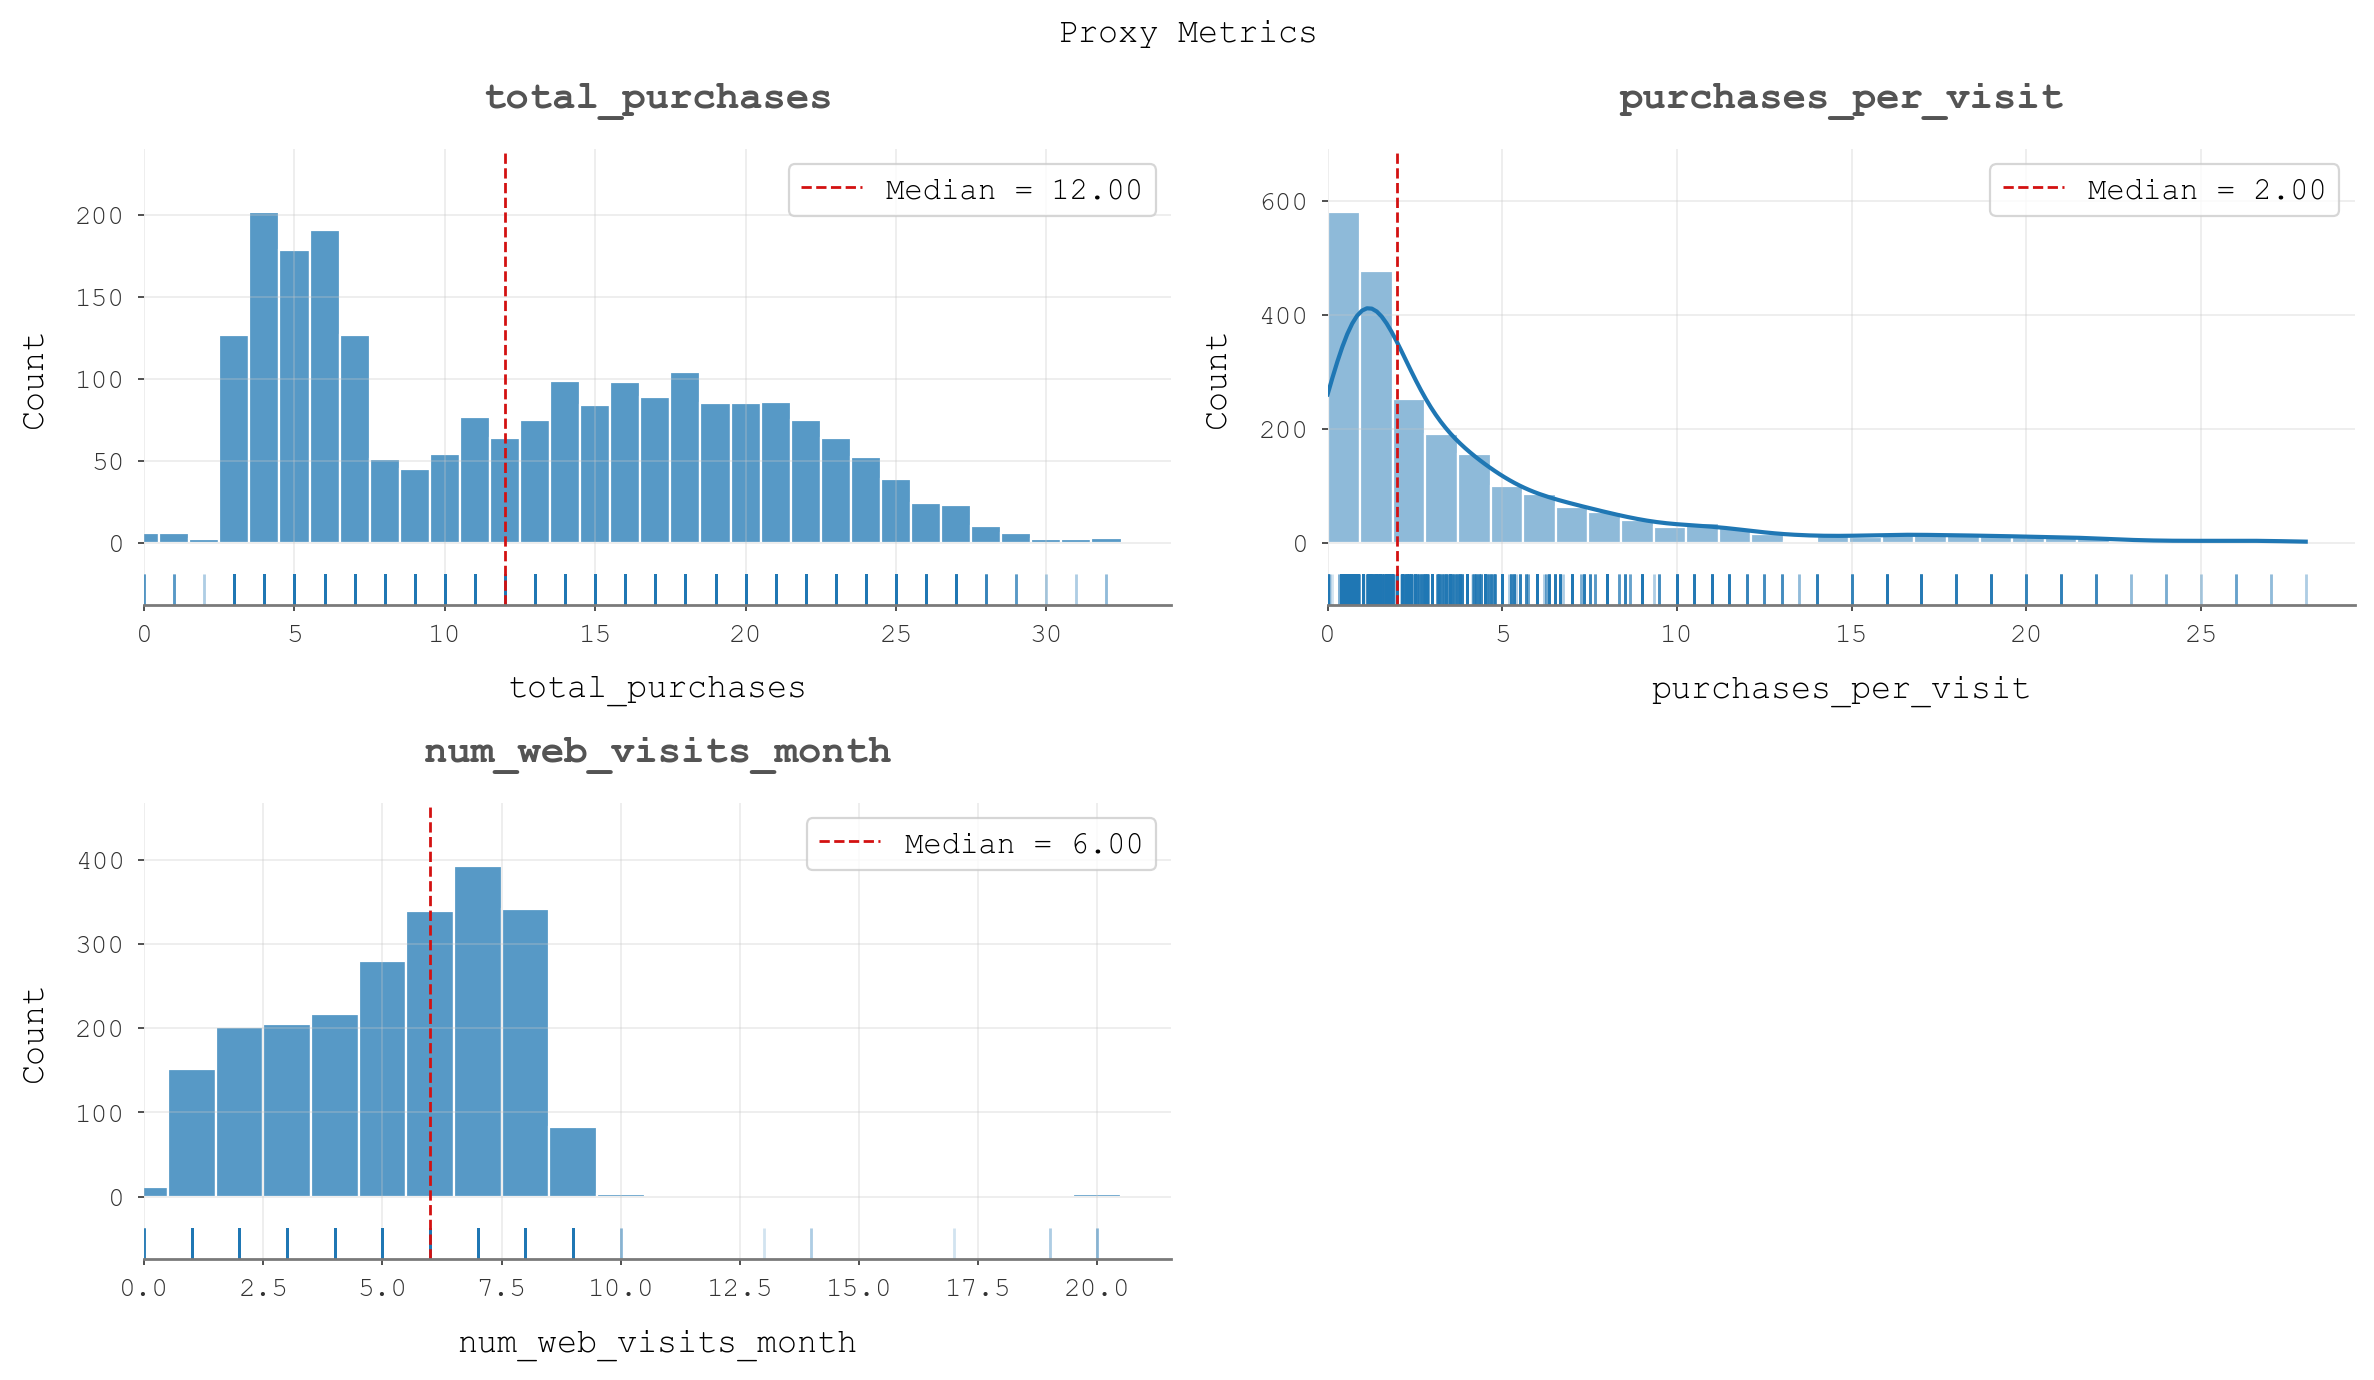

In [268]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for idx, col in enumerate(secondary_metrics):
    median_val = df[col].median()

    sns.rugplot(data=df, x=col, height=0.07, alpha=0.2, ax=axes[idx])
    
    if col in ['total_purchases', 'num_web_visits_month']:
        sns.histplot(data=df, x=col, discrete=True, ax=axes[idx])
    else:
        sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[idx])

    axes[idx].axvline(median_val,
        color=DIMRED, linestyle='--', linewidth=1,
        label=f'Median = {median_val:.2f}'
    )        
    
    axes[idx].set_title(col)
    axes[idx].set_xlim(left=0)
    axes[idx].spines['left'].set_visible(False)
    axes[idx].legend()

for i in range(len(secondary_metrics), 4):
    axes[i].set_visible(False)

plt.suptitle("Proxy Metrics", fontsize=12)
plt.tight_layout()
plt.show()

У total_purchases распределение довольно широкое: есть группа пользователей с небольшим количеством покупок, но заметная часть делает 10–20+ покупок. Медиана около 12, то есть пользователь в среднем покупает регулярно. Изменения в среднем чеке могут происходить как за счет изменения суммы одной покупки, так и за счет изменения частоты.

У purchases_per_visit сильная асимметрия: у большинства пользователей значение низкое, и только у небольшой части высокое. Т.е. чаще всего визиты не заканчиваются покупкой. Метрика чувствительна к редким пользователям и может сильно колебаться.

У num_web_visits_month распределение более компактное, без длинного хвоста. Большинство пользователей делает 5–8 визитов в месяц, медиана около 6. Активность пользователей достаточно стабильна и вряд ли будет главным источником изменений.

В сумме это выглядит так: если эффект появится, он скорее проявится в изменении среднего чека или эффективности покупки (через purchases_per_visit), а не в резком росте числа визитов.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 10px 0;">
Robust preprocessing
</p>

In [269]:
# обработка выбросов
robust = RobustPreprocessor()

robust.fit(
    dataframe=df,
    column_names=['avg_purchase_value', 'purchases_per_visit'],
    alpha=0.01,
    tail='right'
)

df_robust = robust.transform(df)

ambrosia LOGGER: Making right-tail robust transformation of columns ['avg_purchase_value', 'purchases_per_visit']
                 with alphas = [0.01 0.01]
ambrosia LOGGER: 

ambrosia LOGGER: Change Mean avg_purchase_value: 38.0994 ===> 36.1942
ambrosia LOGGER: Change Variance avg_purchase_value: 2105.5459 ===> 788.5154
ambrosia LOGGER: Change IQR avg_purchase_value: 36.1354 ===> 34.8396
ambrosia LOGGER: Change Range avg_purchase_value: 1679.0000 ===> 128.0000
ambrosia LOGGER: 

ambrosia LOGGER: Change Mean purchases_per_visit: 3.9039 ===> 3.7038
ambrosia LOGGER: Change Variance purchases_per_visit: 22.2847 ===> 18.3418
ambrosia LOGGER: Change IQR purchases_per_visit: 3.8750 ===> 3.7917
ambrosia LOGGER: Change Range purchases_per_visit: 28.0000 ===> 22.0000


После робастной обработки дисперсия метрики 'avg_purchase_value' существенно уменишилась (с ~2100 до 788), среднее значение практически не изменилось.

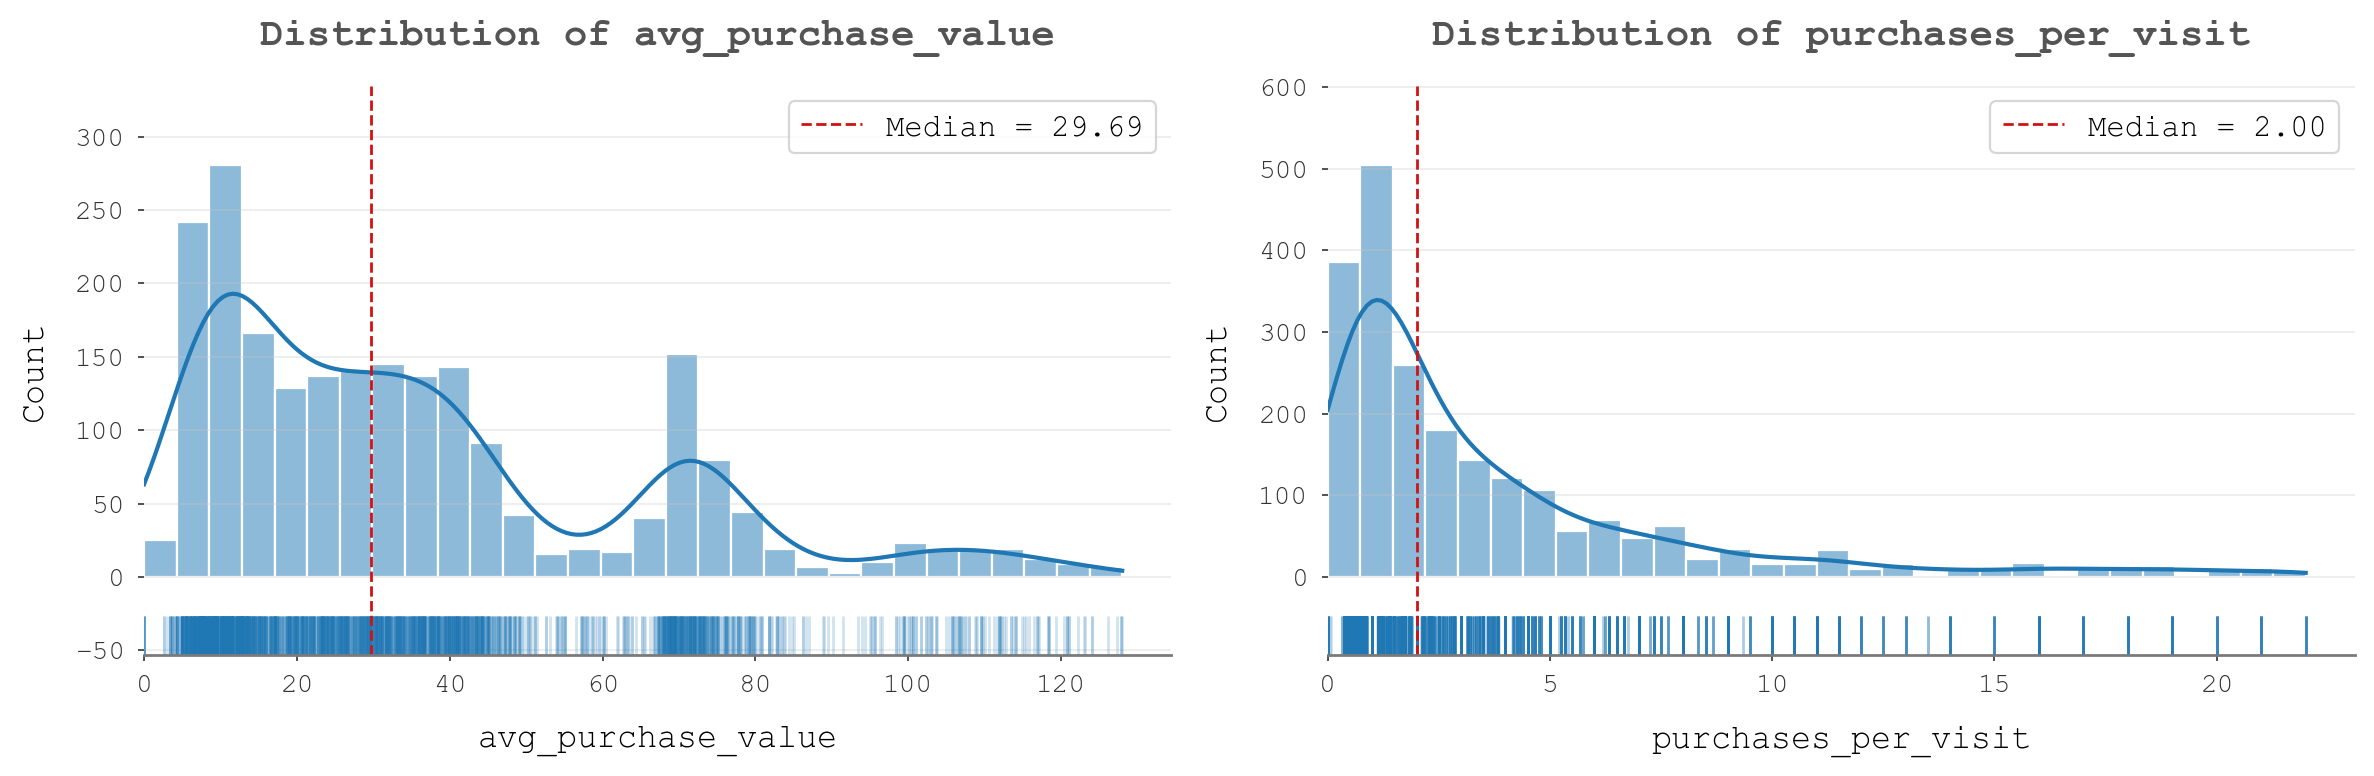

avg_purchase_value skew: 20.807

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.ravel()

columns = ['avg_purchase_value', 'purchases_per_visit']

for idx, col in enumerate(columns):
    median_val = df[col].median()

    sns.rugplot(data=df_robust, x=col, height=0.07, alpha=0.2, ax=axes[idx])
    sns.histplot(data=df_robust, x=col, ax=axes[idx], bins=30, kde=True)

    axes[idx].axvline(median_val,
        color=DIMRED, linestyle='--', linewidth=1,
        label=f'Median = {median_val:.2f}'
    )        
    
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_xlim(left=0)
    axes[idx].spines['left'].set_visible(False)
    axes[idx].grid(axis='x', visible=False)
    axes[idx].legend()

plt.tight_layout()
plt.show()

print(f"avg_purchase_value skew: {df['avg_purchase_value'].skew():.3f}")

После robust-преобразования центральная часть распределения метрики avg_purchase_value практически не изменилась, медиана почти не сдвинулась. Правосторонная асимметрия сохранилась, но коэффициент асимметрии снизился с ~20.8 до 1.07. 

Преобразование не повлияло на типичный уровень среднего чека, но дисперсия снизилась дисперсия (с ~2105 до ~788). Снижение дисперсии влияет на мощность теста – при меньшем std для обраружения эффекта требуется меньший размер выборки.

Для purchases_per_visit ситуация аналогичная: медиана (~2) и форма распределения сохранились, но экстремальные значения сгладились.

In [271]:
print('df std by clusters', df.groupby('cluster_kmeans')['avg_purchase_value'].std(),'\n')

print('df_robust std by clusters', df_robust.groupby('cluster_kmeans')['avg_purchase_value'].std())

df std by clusters cluster_kmeans
0    27.080401
1    64.812433
2    17.705536
Name: avg_purchase_value, dtype: float64

df_robust std by clusters cluster_kmeans
0    25.029936
1    32.211534
2    16.010409
Name: avg_purchase_value, dtype: float64

Робастная обработка сильнее всего повлияла на самый "шумный" сегмент 1 (Wine & meat), снизив std c 64 до 32; после обработки его вариативность стала сопоставима с другими сегментами.

In [274]:
df = df_robust.copy()

### Распределения по кластерам

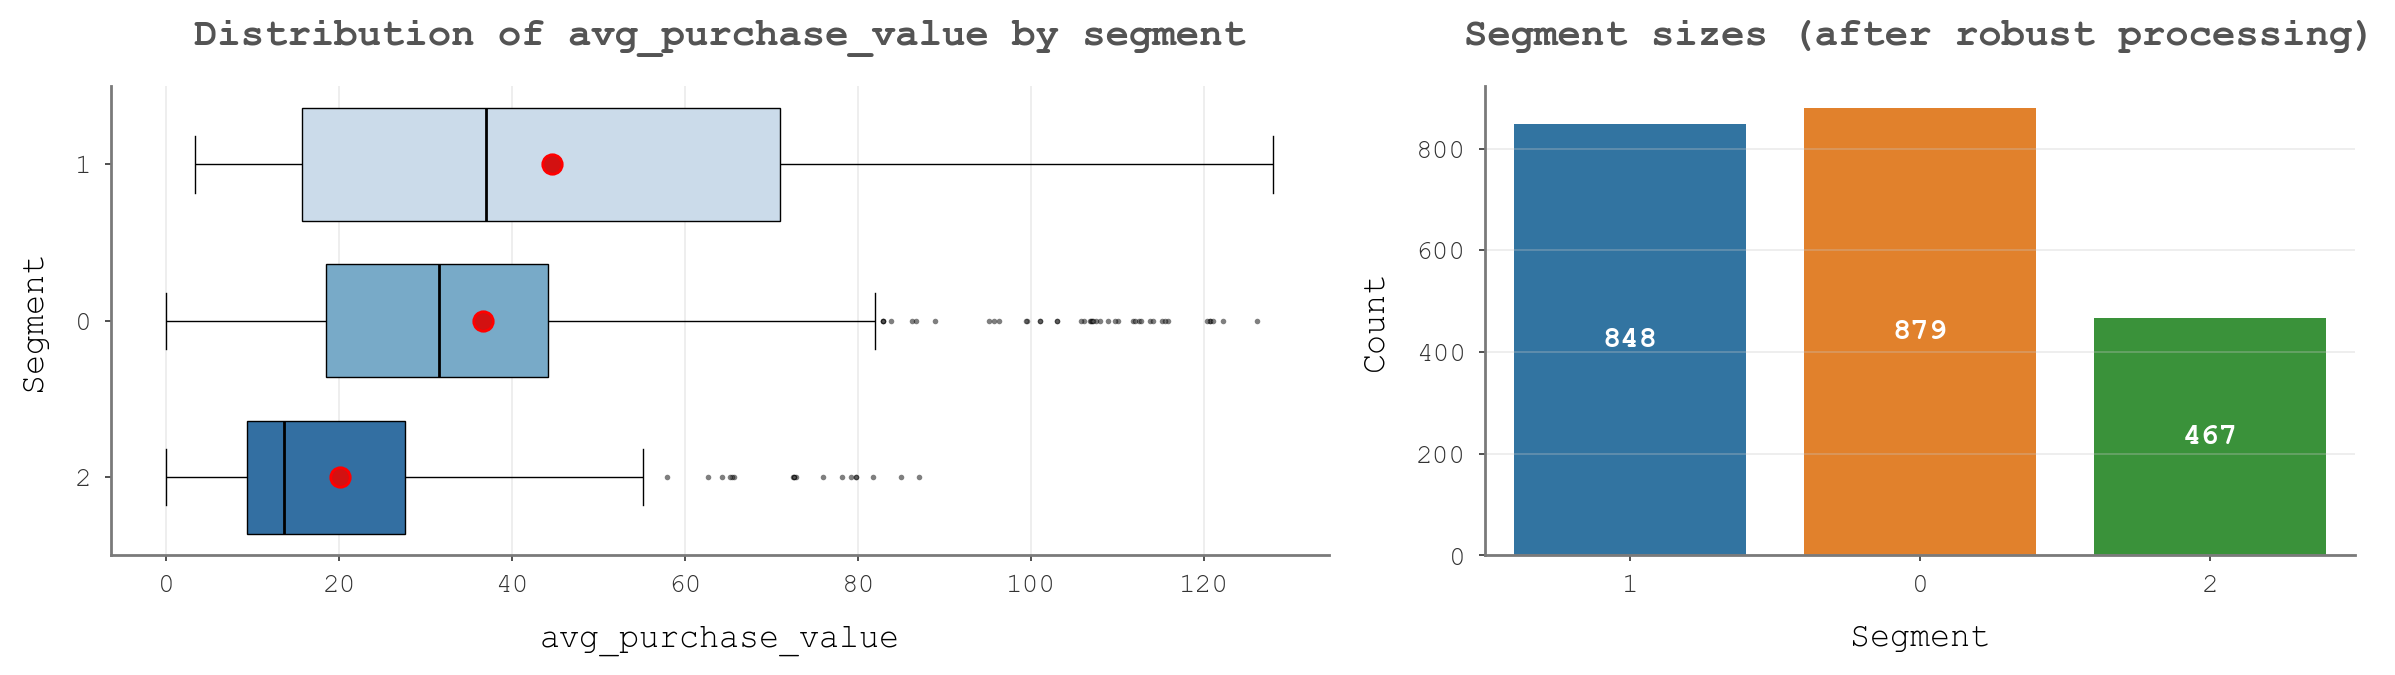

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={'width_ratios': [1.4, 1]})

df['cluster_kmeans'] = df['cluster_kmeans'].astype(str)
df_robust['cluster_kmeans'] = df_robust['cluster_kmeans'].astype(str)

sns.boxplot(hue='cluster_kmeans', x='avg_purchase_value', y='cluster_kmeans', data=df, 
            palette='Blues', color=COLOR, gap=0.1, ax=axes[0], **BOXPLOT_STYLE)

axes[0].set_ylabel('Segment')
axes[0].set_xlabel('avg_purchase_value')
axes[0].set_title('Distribution of avg_purchase_value by segment')

ax = sns.countplot(data=df_robust, x='cluster_kmeans', hue='cluster_kmeans', palette='tab10', ax=axes[1])

axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].set_title('Segment sizes (after robust processing)')

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()


**Слева**\
Наибольшая вариативность в сегменте 1 делает его наиболее сложным для обнаружения статистически значимого эффекта. 

**Справа**\
Размеры сегментов различаются: сегменты 0 и 1 имеют сопоставимый объем (~850–880 пользователей), тогда как сегмент 2 значительно меньше (~470 пользователей). 

При стратификации по сегментам высокая вариативность в сегменте 1  увеличивает требуемый размер выборки, а в сегменте 2 меньший объем данных ограничивает доступное количество наблюдений. В обоих случаях это усложняет обнаружение статистически значимого эффекта внутри сегментов.

---

# Теоретический дизайн эксперимента

## Расчет размера выборки

In [ ]:
# метрики эксперимента
primary_metric = 'avg_purchase_value'

secondary_metrics = [
    'total_purchases',
    'purchases_per_visit'
]

In [ ]:
# параметры распределения 'avg_purchase_value' после обработки
mean = df['avg_purchase_value'].mean()
std = df['avg_purchase_value'].std()

print(f"Mean: {mean:.3f}, std: {std:.3f}")

Mean: 36.194, std: 28.087

In [ ]:
# размер доступной выборки
print(f"Available sample: {df.shape[0]}")

# распределение покупателй по сегментам
print(df['cluster_kmeans'].value_counts())

Available sample: 2194

cluster_kmeans
0    879
1    848
2    467
Name: count, dtype: int64

In [ ]:
# параметры AB теста
alpha = 0.05
beta = 0.2
power = 1 - beta

In [ ]:
# расчет необходимого размера выборки для AB теста
from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

for mde in [0.05, 0.1, 0.15]:
    effect = mean * mde
    cohen_d = effect / std
    
    sample_size = analysis.solve_power(
        effect_size=cohen_d,
        alpha=alpha,
        power=power
    )
    
    print(f"\nMDE: {int(mde*100)}% \n",
          f"Sample per group: {int(sample_size)}\n",
          f"Total needed: {int(sample_size*2)}")

MDE: 5% 
 Sample per group: 3782
 Total needed: 7564

MDE: 10% 
 Sample per group: 946
 Total needed: 1892

MDE: 15% 
 Sample per group: 421
 Total needed: 842

Всего доступно 2179 пользователей. Размер сегментов составляет 888 / 876 / 467 пользователей. При разделении каждого сегмента на равные АВ группы 50/50 размеры групп внутри каждого сегмента ~ 444 / 438 / 233 пользователей на группу.

Согласно расчетам, для обнаружения эффекта 10% требуется ~900 наблюдений на группу, это превышает доступный объем данных во всех сегментах. Даже для эффекта 15% достаточный объем наблюдений достигается только в двух сегментах, тогда как в третьем сегменте данных недостаточно. Это увеличивает риск не обнаружить эффект даже при его наличии (ошибка второго рода).

Проведение A/B теста на уровне сегментов не позволяет достичь достаточной статистической мощности. Тест выполняется на всей выборке, а сегменты используются для последующего анализа результатов.

In [ ]:
# валидация расчета размера выборки (Ambrosia)

designer = Designer()

design = designer.run(
    to_design='size',
    dataframe=df,
    metrics='avg_purchase_value',
    first_type_errors=alpha,   
    second_type_errors=beta,  
    effects=1.15,               # +15% 
    method='theory',
    alternative='two-sided',
    stabilizing_method='norm'
)

print(design)

Errors ($\alpha$, $\beta$) (0.05; 0.2)
Effect                                
15.0%                              422

Расчет размера выборки на группу с использованием *Ambrosia* подтверждает, что для MDE 15% требуется 422 наблюдения в каждой группе.

## A/A test

### Random split. Проверка баланса

В рамках A/A тестирования пользователи случайным образом распределяются на две группы (A и B). Предполагается, что между ними нет различий. \
Проверим, как часто тест находит различия при их отсутствии.

In [ ]:
# random split
rng = np.random.default_rng(1)

df['group'] = rng.choice(['A', 'B'], size=len(df))

# размеры групп
group_sizes = df['group'].value_counts().to_frame('count')
group_sizes['share'] = (group_sizes['count'] / len(df)).round(3)

print(group_sizes)

count  share
group              
B       1111  0.506
A       1083  0.494

Размеры групп близки к равным (~50/50), что соответствует ожидаемому случайному распределению.

In [ ]:
display(
    df.groupby('group').agg({
        'avg_purchase_value': ['mean', 'std'],
        'total_purchases': 'mean',
        'purchases_per_visit': 'mean'
    })
)

avg_purchase_value            total_purchases purchases_per_visit
                    mean        std            mean                mean
group                                                                  
A              35.450891  28.107682       12.223453            3.575959
B              36.918731  28.060360       12.683168            3.828492

Средние значения метрик между группами немного отличаются в зависимости от значения random seed, что ожидаемо при случайном разбиении. Разброс значений (std) сопоставим, а по дополнительным метрикам различия несущественны.

### Проверка статистических различий

t-test для двух независимых выборок

H0: средние в группах одинаковые  \
H1: средние различаются

In [ ]:
# статзначимость различий основной метрики - t-test

from ambrosia.tester import Tester

tester = Tester()

result = tester.run(
    dataframe=df,
    metrics='avg_purchase_value',
    column_groups='group',
    criterion='ttest'
)

print(result)

first_type_error    pvalue   effect confidence_interval         metric name group A label group B label
0              0.05  0.221099  1.46784   (-0.8845, 3.8202)  avg_purchase_value             A             B

Результат t-test показывает, что различия в основной метрике групп А и В статистически незначимы. P-value ~0.221 (> 0.05), поэтому нулевая гипотеза не отвергается.
Оценка эффекта ~1.47, но доверительный интервал (−0.88; 3.82) включает ноль, то есть устойчивого различия между группами нет.

Cлучайное разбиение пользователей можно считать корректным.

Случайное разбиение корректно, систематических различий между группами не видно. Это позволяет использовать случайное разбиение для проведения A/B теста.

---

## Проверка устойчивости теста

Проведем серию A/A тестов с многократным случайным разбиением пользователей на группы чтобы проверить как часто тест дает ложноположительный результат (ошибка I рода), а также оценить распределение разности средних и p-value при отсутствии эффекта.

In [ ]:
df_aa = df.copy()

In [ ]:
# multiple t-tests

alpha=0.05
n_tests = 2000

p_values_aa = []
diff_means_aa = []

# N тестов АА с random split
for _ in range(n_tests):
    df_aa['group'] = rng.choice(['A', 'B'], size=len(df_aa))
    
    group_A = df_aa[df_aa['group'] == 'A']['avg_purchase_value']
    group_B = df_aa[df_aa['group'] == 'B']['avg_purchase_value']

    # разница средних для анализа распределения
    diff = group_A.mean() - group_B.mean()
    diff_means_aa.append(diff)
    
    # p-value t-test
    _, p = ttest_ind(group_A, group_B, equal_var=False)
    p_values_aa.append(p)

# доля ошибок 1 рода 
p_hat = np.mean(np.array(p_values_aa) < alpha)
n = len(p_values_aa)

# стандартная ошибка (при H0: p = alpha)
se = np.sqrt(alpha * (1 - alpha) / n)

# ожидаемый диапазон p_hat
lower = alpha - 1.96*se
upper = alpha + 1.96*se

print(f'False positive rate= {p_hat:.3f}')
print(f'Expected range= [{lower:.3f}, {upper:.3f}]')
print(f'Within expected range: {lower <= p_hat <= upper}')

False positive rate= 0.063

Expected range= [0.040, 0.060]

Within expected range: False

Доля ошибок первого рода (0.043) близка к заданному уровню значимости (α = 0.05) и находится в ожидаемом диапазоне [0.041, 0.059], который включает alpha. Тест работает как ожидается.

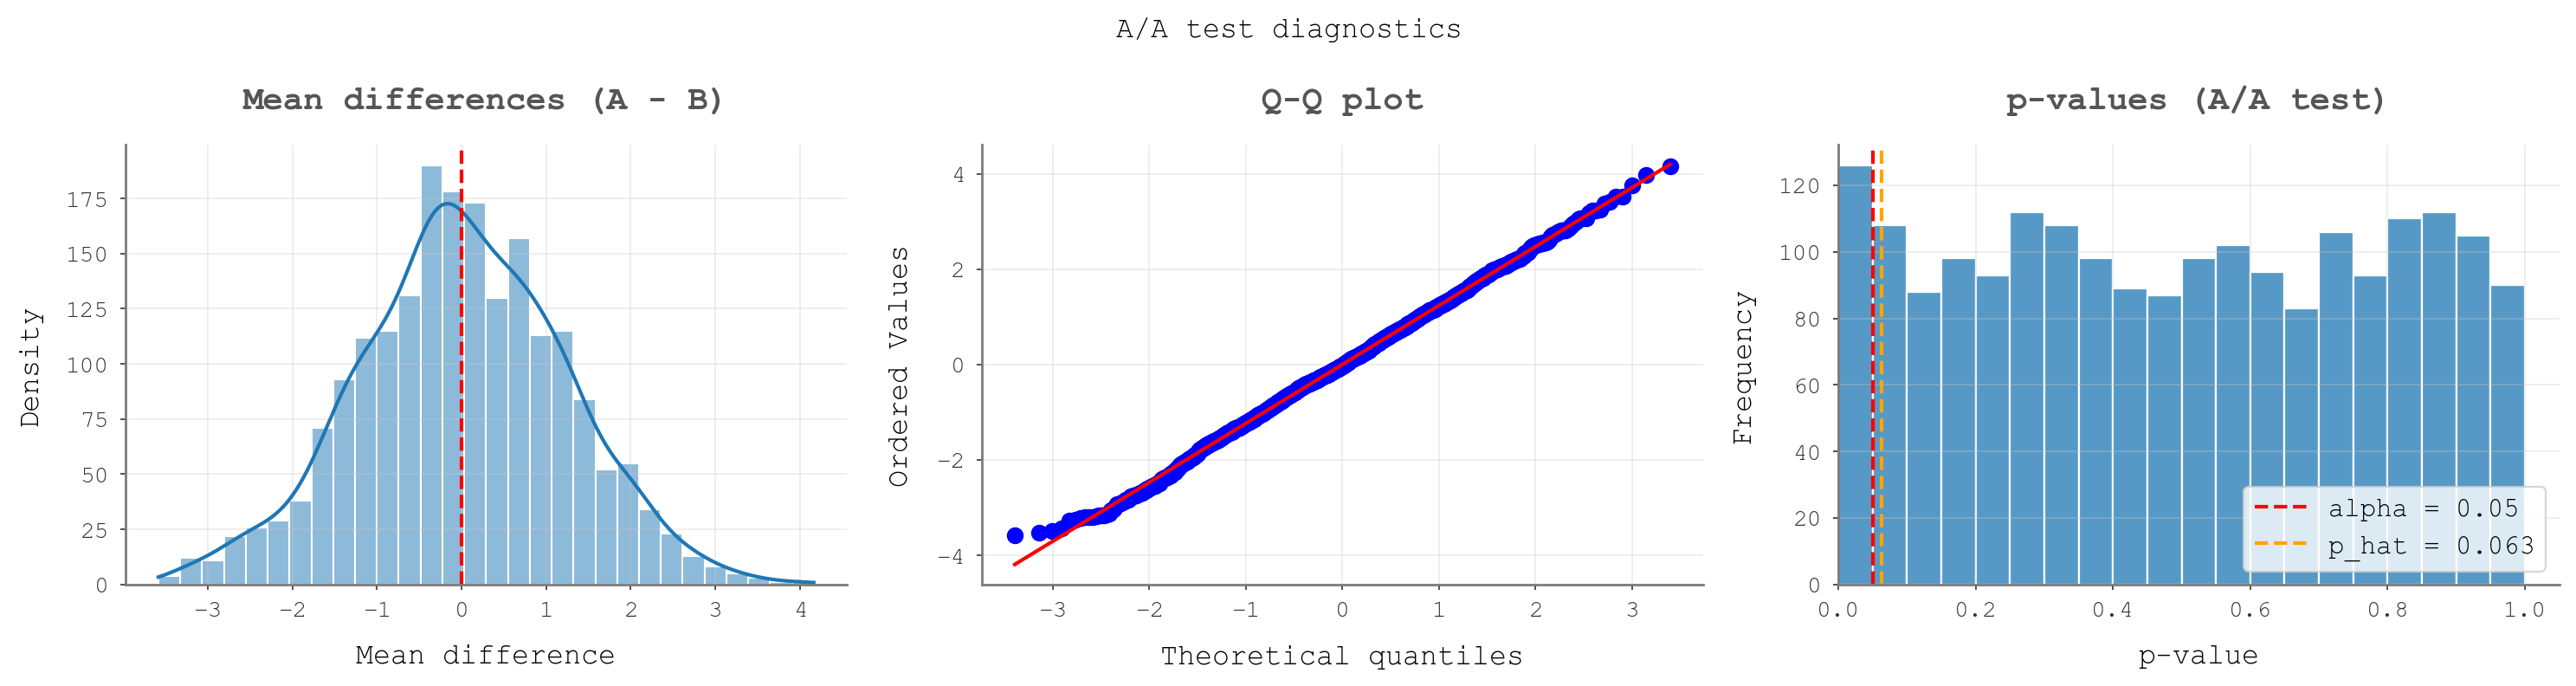

mean=0.00, std=1.24

In [ ]:
alpha = 0.05

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# гистограмма разности средних 
sns.histplot(diff_means_aa, bins=30, kde=True, ax=axes[0])
axes[0].axvline(0, linestyle='--', color='red')

axes[0].set_title('Mean differences (A - B)')
axes[0].set_xlabel('Mean difference')
axes[0].set_ylabel('Density')

# Q-Q plot
stats.probplot(diff_means_aa, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot')

# p-values 
bins = np.linspace(0, 1, 21)
sns.histplot(p_values_aa, bins=bins, kde=False, ax=axes[2])
axes[2].axvline(alpha, linestyle='--', color='red', label=f'alpha = {alpha}')
axes[2].axvline(p_hat, linestyle='--', color='orange', label=f'p_hat = {p_hat:.3f}')

axes[2].set_xlim(left=0)
axes[2].set_title('p-values (A/A test)')
axes[2].set_xlabel('p-value')
axes[2].set_ylabel('Frequency')
axes[2].legend(loc='lower right')

plt.suptitle('A/A test diagnostics', fontsize=12)
plt.tight_layout()
plt.show()

mean_aa = np.mean(diff_means_aa)
std_aa = np.std(diff_means_aa)

print(f"mean={mean_aa:.2f}, std={std_aa:.2f}")

- **Mean differences histplot, qq-plot**: несмотря на скошенное распределение метрики и выбросы, t-test работает стабильно – размер выборки достаточно большой, ЦПТ делает распределение средних близким к нормальному.

- **p-value distribution**: распределение p-value в A/A тесте близко к равномерному, как и ожидается при отсутствии различий между группами. Около 5% p-value ниже alpha = 0.05, это соответствует ожидаемому уровню ошибок первого рода для t-test.

In [ ]:
# сравнение avg_purchase_value по кластерам и группам
df.groupby(['cluster_kmeans', 'group'])['avg_purchase_value'].mean()

cluster_kmeans  group
0               A        35.907147
                B        37.224357
1               A        44.612416
                B        44.687188
2               A        19.322310
                B        20.970888
Name: avg_purchase_value, dtype: float64

In [ ]:
# # t-test по кластерам
for cluster in df['cluster_kmeans'].unique():
    sub = df[df['cluster_kmeans'] == cluster]
    
    group_A = sub[sub['group'] == 'A']['avg_purchase_value']
    group_B = sub[sub['group'] == 'B']['avg_purchase_value']
    
    _, p = ttest_ind(group_A, group_B)
    print(f"Cluster {cluster}, p-value {round(p, 3)}")

Cluster 1, p-value 0.973

Cluster 0, p-value 0.436

Cluster 2, p-value 0.267

Во всех кластерах различия между группами A и B статистически незначимы (p-value > 0.05).

---

# Эмпирический дизайн эксперимента

### A/B тест

In [ ]:
df_ab = df.copy()

In [ ]:
# размеры групп

group_sizes = df['group'].value_counts().to_frame('count')
group_sizes['share'] = (group_sizes['count'] / len(df)).round(3)

print(group_sizes)

count  share
group              
B       1111  0.506
A       1083  0.494

In [ ]:
# добавляем эффект 15%

df_ab.loc[df_ab['group'] == 'B', 'avg_purchase_value'] *= 1.15

In [ ]:
# AB тест с добавленным эффектом

A = df_ab[df_ab['group'] == 'A']['avg_purchase_value']
B = df_ab[df_ab['group'] == 'B']['avg_purchase_value']

t_stat, p_value = ttest_ind(A, B, equal_var=False)

print(f"t-stat {t_stat.round(4)}; p-value {p_value.round(4)}")

t-stat -5.4264; p-value 0.0

После добавления эффекта (увеличение среднего чека на 15% в группе B) t-test показывает статистически значимые различия между группами (p-value < 0.05).

При размере выборки ~1000 на группу тест способен обнаружить эффект масштаба MDE 15%, что соответствует теоретическим расчетам.

### Оценка параметров эксперимента

In [ ]:
# функция симуляции A/B теста

def simulate_ab_test(data, sample_size, effect=0.0, n_sim=1000, alpha=0.05):
    p_values_ab = []
    diff_means_ab = []
    
    for _ in range(n_sim):
        sample = data.sample(n=2 * sample_size, replace=False)
        
        group_A = sample.iloc[:sample_size]
        group_B = sample.iloc[sample_size:].copy()
        
        # добавляем эффект
        group_B['avg_purchase_value'] *= (1 + effect)
        
        # разница средних
        diff = group_B['avg_purchase_value'].mean() - group_A['avg_purchase_value'].mean()
        diff_means_ab.append(diff)
        
        # t-test
        _, p = ttest_ind(
            group_A['avg_purchase_value'],
            group_B['avg_purchase_value'],
            equal_var=False
        )
        
        p_values_ab.append(p)
    
    power = np.mean(np.array(p_values_ab) < alpha)
    
    return power, p_values_ab, diff_means_ab

##### **Оценка мощности теста**

In [ ]:
# эмпирическая оценка мощности теста

alpha = 0.05
n_sim = 2000
sample_size = 420   # из теоретического расчета
effect = 0.15       # 15%

power, _, _ = simulate_ab_test(
    df,
    sample_size=sample_size,
    effect=effect,
    n_sim=n_sim,
    alpha=alpha
)

print(f'N={sample_size}, effect {effect}: power {power:.3f}')

N=420, effect 0.15: power 0.729

Полученная оценка мощности при размере выборки ~420 наблюдений на группу составляет около 0.73, что ниже предполагаемого уровня (0.8).

Значит тест не всегда способен обнаружить MDE 15% на таком объеме выборки. Теоретическая оценка мощности оказалась немного завышенной по сравнению с эмпирической.

In [ ]:
# оценка мощности для разных N

sample_sizes = [300, 420, 550, 650, 800, len(df)//2]

powers = []

for n in sample_sizes:
    power, _, _ = simulate_ab_test(df, sample_size=n, effect=0.15, n_sim=1000)
    powers.append(power)

pd.DataFrame({
    'sample_size': sample_sizes,
    'power': powers
})

,sample_size,power
0,300,0.630
1,420,0.723
2,550,0.860
3,650,0.910
4,800,0.953
5,1097,0.989


Мощность теста растет с увеличением размера выборки, но при размере ~420 наблюдений на группу мощность составляет около 0.73, планируемого уровня power=0.8.

Нужная мощность теста достигается при размере выборки от 520 наблюдений на группу. При использовании всего доступного объема (~1090 на группу) мощность близка к 1, что означает практически гарантированное обнаружение эффекта MDE 15%.

##### **Оценка MDE** при фиксированном размере выборки

In [ ]:
# оценка MDE при фиксированном N

sample_size = 420

effects = np.linspace(0.05, 0.25, 10)
powers = []

for eff in effects:
    power, _, _ = simulate_ab_test(df, sample_size=sample_size, effect=eff, n_sim=1000)
    powers.append(power)

mde_df = pd.DataFrame({
    'effect': effects,
    'power': powers
})

mde_df.round(2)

,effect,power
0,0.05,0.16
1,0.07,0.25
2,0.09,0.39
3,0.12,0.56
4,0.14,0.66
5,0.16,0.80
6,0.18,0.90
7,0.21,0.94
8,0.23,0.97
9,0.25,0.98


In [ ]:
mde_df[mde_df['power'] >= 0.8].head(1).round(2)

,effect,power
5,0.16,0.8


При фиксированном размере выборки (согласно теоретическим расчетам 420 наблюдений на группу) мощность теста достигает уровня ~0.8 при MDE около 17–18%. Это превышает 15%, принятую в теоретическом расчете.

Теоретическая оценка MDE оказалась слишком оптимистична для такого объема выборки. Для сохранения MDE на уровне 15% нужна большая выборка, что согласуется с предыдущим анализом зависимости MDE от размера выборки, где эмпирический расчет размера выборки составил ~520 наблюдений на группу.

##### **Оценка длительности эксперимента**

In [ ]:
# длительность эксперимента

sample_size = 550           # реалистичная оценка размера групп

users_total = len(df)
users_per_day = users_total / 30

duration_days = (sample_size * 2) / users_per_day

print(f'Users per day: {users_per_day:.1f}')
print(f'Duration (days): {duration_days:.1f}')

Users per day: 73.1

Duration (days): 15.0

При текущем потоке пользователей необходимый объем выборки (550 * 2) может быть набран примерно за 15 дней. С учетом недельной сезонности длительность эксперимента увеличивается до 3 недель минимум.

### Вывод

Эмпирическая оценка параметров эксперимента показала, что теоретический расчет размера выборки (~420 наблюдений на группу) слишком оптимистичен, при таком объеме мощность теста составляет около 0.73 и не достигает желаемого уровня 0.8.

По результатам симуляции для обнаружения MDE 15% нужно увеличить выборку до ~550 наблюдений на группу. При размере выборки 420 наблюдений MDE составляет около 17–18%.

При использовании всего доступного объема данных (~1090 пользователей на группу) мощность теста близка к 1, что позволяет надежно обнаружить MDE 15%.

С учетом текущего потока пользователей необходимый объем данных (~1200 наблюдений) может быть набран примерно за 15 дней. С учетом недельной сезонности длительность эксперимента устанавливается на уровне 3 недель.



---

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Сравнение теоретического и эмпирического дизайна
</p>

Теоретический расчет размера выборки выполнен при допущении нормального распределения метрики и при использовании оценок среднего и стандартного отклонения метрики, рассчитанных по данным. При эффекте 15% расчет дает ~420 наблюдений на группу.

Эмпирическая оценка основана на симуляциях: из исходных данных многократно формируются выборки заданного размера, в одну из групп добавляется эффект, после чего считается доля случаев, в которых t-test возвращает p-value < 0.05. Эта доля интерпретируется как мощность теста.

Для размера 420 наблюдений на группу получена мощность ~0.73, что ниже целевого уровня 0.8. Значит в ~27% случаев тест не обнаружит эффект 15% даже при его наличии. Расхождение связано с тем, что распределение метрики асимметрично и содержит выбросы, что увеличивает разброс значений и снижает чувствительность t-test. Теоретическая модель эти особенности не учитывает.

По результатам симуляций для достижения мощности ≥ 0.8 требуется ~520-550 наблюдений на группу.

**Вывод**: теоретический расчет можно использовать как начальную оценку, но финальные параметры эксперимента определяем на основе эмпирической проверки, т.к. она учитывает фактическое распределение данных. Эксперимент проводится на всей выборке без стратификации; сегменты используются для последующего анализа результатов.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Финальные параметры эксперимента
</p>

- Размер групп: не менее 520–550 пользователей на группу (по результатам эмпирической оценки).
- Сплит: 50/50 между группами A и B.
- Общий размер выборки: ~1040–1100 пользователей.
- Длительность эксперимента: при текущем потоке ~73 пользователя в день это ~15 дней набора данных. С учетом недельной сезонности – не менее 2-3 недель.



<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Критерии принятия решения
</p>

Решение принимается по основной метрике AvgPurchaseValue: сравнивается средний чек в группах A и B.

Для проверки различий используется t-test. Результат считается статистически значимым, если p-value < 0.05, то есть вероятность получить такое различие при отсутствии реального эффекта меньше 5%.

Важен не только факт статзначимости, но и размер эффекта: рост среднего чека в группе B должен быть не ниже целевого уровня (MDE ~15%), чтобы иметь практический смысл для бизнеса.

Если p-value < 0.05 и средний чек в группе B выше, чем в группе A, и рост соответствует MDE, гипотеза о положительном влиянии персонализации принимается, и решение может быть внедрено.

Если p-value ≥ 0.05, различия считаются случайными, и гипотеза не подтверждается.

Дополнительно анализируем NumPurchases и PurchasesPerVisit, чтобы понять, за счет чего изменился средний чек, за счет роста количества покупок или изменения поведения пользователей.

Также результаты проверяются по сегментам пользователей, чтобы увидеть, одинаково ли работает персонализация для разных групп. Если эффект наблюдается только в некоторых сегментах, это учитывается при принятии решения и может потребовать дополнительного тестирования.

<p style="font-weight: 700; font-size: 1.2em; color: teal; padding: 5px 0;">
Интерпретация результатов АВ теста
</p>

Рост AvgPurchaseValue в группе B означает, что персонализация приводит к увеличению среднего чека на пользователя. Это может происходить за счет двух механизмов: увеличения количества покупок (NumPurchases) или увеличения суммы одной покупки.

Если одновременно растут AvgPurchaseValue и NumPurchases, пользователи покупают чаще и тратят больше, что указывает на общий рост вовлеченности.

Если растет AvgPurchaseValue при стабильном NumPurchases, пользователи совершают покупки с большей суммой, что указывает на успешную рекомендацию более дорогих или дополнительных товаров.

Если рост AvgPurchaseValue сопровождается ростом PurchasesPerVisit, это означает, что визиты чаще заканчиваются покупкой, то есть меняется поведение пользователя внутри сессии.

Отсутствие значимого эффекта означает, что выбранная логика персонализации не влияет на поведение пользователей и не приводит к росту выручки. В этом случае требуется пересмотр гипотезы или механики рекомендаций.